# Clustering de vinos: descubrimiento y caracterización de tipos de vino tinto

**Aprendizaje Artificial · Maestría en Inteligencia Artificial (CAECE) · Unidad 2: Clustering**

Este notebook desarrolla de punta a punta un trabajo de **aprendizaje no supervisado** sobre el *Wine Data Set* de UCI
(178 vinos tintos del Piamonte, 13 variables químicas). Se sigue la metodología **CRISP-DM** y cada sección se organiza como
*contexto → decisión → justificación → resultado*, en línea con la consigna de la cátedra: "no se trata de apretar un botón sino de usar la cabeza".

**Índice**
1. Comprensión del negocio
2. Comprensión de los datos (EDA)
3. Preparación de los datos (escalado, outliers, distancia)
4. Modelado: elección de k, K-Means, estabilidad y modelo jerárquico alternativo
5. Evaluación e interpretación de los clusters
6. Los tipos de vino identificados (nombres y perfiles)
7. Validación post-hoc con las etiquetas ocultas
8. Limitaciones y conclusiones

Toda la lógica vive en el paquete `src/` (el notebook solo la invoca y narra); `python -m src.run_all` regenera las mismas figuras y tablas en `outputs/`.

In [1]:
import sys, warnings
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from src.data import SEMILLA, cargar_vinos, cargar_etiquetas_ocultas, fijar_semillas
from src import eda, preprocessing as pp, clustering as cl, interpretation as it

fijar_semillas(SEMILLA)           # random_state=42 en todo lo estocástico
warnings.simplefilter("default")  # cualquier warning quedaría visible en la salida
pd.set_option("display.precision", 3)
pd.set_option("display.width", 200)
%matplotlib inline

## 1. Comprensión del negocio

**Objetivo.** Descubrir cuántos *tipos* de vino existen en los datos a partir de su perfil químico, **sin usar etiquetas**, y
nombrarlos de forma interpretable para un enólogo o un área comercial (por ejemplo, para definir líneas de producto, segmentos de precio o recomendaciones de maridaje).

**Por qué es un problema de clustering y no de clasificación.** En clasificación (aprendizaje supervisado) existe una variable
objetivo (*target*) conocida y el modelo aprende a predecirla con un esquema de entrenamiento/prueba (*train/test*). Aquí la
variedad de uva fue **eliminada** del dataset: no hay target, no hay train/test y el algoritmo debe encontrar la estructura por sí
mismo. El criterio es el clásico del clustering: **mínima distancia intra-cluster y máxima distancia inter-cluster**.

**Qué *no* sería clustering.** Segmentar los vinos con una regla arbitraria (por ejemplo, "alcohol > 13 % = premium") o con el
resultado de una consulta (*query*) no es aprendizaje: la partición la impone quien escribe la regla, no la emerge de la similitud
multivariada entre los vinos.

**Decisiones que hay que justificar** (marco de la cátedra): (1) medida de distancia, (2) escalado de variables, (3) cantidad de
clusters *k* y (4) algoritmo (particional —K-Means— o jerárquico aglomerativo con distintos *linkage*).

## 2. Comprensión de los datos (EDA)

Como insiste la cátedra, "siempre hay que ver cómo está conformado el dataset" antes de modelar. Se usa el CSV provisto por la
cátedra, `data/raw/wine-clustering.csv` (versión de Kaggle del dataset de UCI, **ya sin la variedad**). Sus columnas vienen en inglés
(`Malic_Acid`, `Ash_Alcanity`, `OD280`, …) y se renombran automáticamente a los 13 nombres en español.

Para poder hacer la validación post-hoc de la sección 7 se verificó que el CSV coincide **fila a fila** con el dataset original de
UCI (`sklearn.datasets.load_wine()`); por eso la variedad real se recupera de allí y **se guarda aparte en
`data/raw/etiquetas_ocultas.csv`**. No forma parte del dataframe de trabajo ni se vuelve a mirar hasta la sección 7.

In [2]:
df = cargar_vinos()
print("Dimensiones:", df.shape)
print("Nulos totales:", df.isna().sum().sum(), "| Filas duplicadas:", df.duplicated().sum())
df.info()
df.head()

Dimensiones: (178, 13)
Nulos totales: 0 | Filas duplicadas: 0
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Alcohol                   178 non-null    float64
 1   Ácido málico              178 non-null    float64
 2   Ceniza                    178 non-null    float64
 3   Alcalinidad de la ceniza  178 non-null    float64
 4   Magnesio                  178 non-null    float64
 5   Fenoles totales           178 non-null    float64
 6   Flavonoides               178 non-null    float64
 7   Fenoles no flavonoides    178 non-null    float64
 8   Proantocianinas           178 non-null    float64
 9   Intensidad del color      178 non-null    float64
 10  Tono                      178 non-null    float64
 11  OD280/OD315               178 non-null    float64
 12  Prolina                   178 non-null    float64
dtypes: float64(13)

,Alcohol,Ácido málico,Ceniza,Alcalinidad de la ceniza,Magnesio,Fenoles totales,Flavonoides,Fenoles no flavonoides,Proantocianinas,Intensidad del color,Tono,OD280/OD315,Prolina
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83
Ácido málico,178.0,2.336,1.117,0.74,1.603,1.865,3.083,5.80
Ceniza,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23
Alcalinidad de la ceniza,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00
Magnesio,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00
Fenoles totales,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88
Flavonoides,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08
Fenoles no flavonoides,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66
Proantocianinas,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58
Intensidad del color,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00


In [4]:
eda.resumen_basico(df)

,tipo,nulos,mínimo,máximo,media,desvío,coef. variación
Alcohol,float64,0,11.03,14.83,13.001,0.812,0.062
Ácido málico,float64,0,0.74,5.80,2.336,1.117,0.478
Ceniza,float64,0,1.36,3.23,2.367,0.274,0.116
Alcalinidad de la ceniza,float64,0,10.60,30.00,19.495,3.340,0.171
Magnesio,float64,0,70.00,162.00,99.742,14.282,0.143
Fenoles totales,float64,0,0.98,3.88,2.295,0.626,0.273
Flavonoides,float64,0,0.34,5.08,2.029,0.999,0.492
Fenoles no flavonoides,float64,0,0.13,0.66,0.362,0.124,0.344
Proantocianinas,float64,0,0.41,3.58,1.591,0.572,0.360
Intensidad del color,float64,0,1.28,13.00,5.058,2.318,0.458


Los 178 vinos y las 13 variables son numéricas continuas (`float64`), sin nulos ni duplicados: **no se requiere imputación** y
K-Means (que solo admite variables numéricas) es aplicable. Ya en la tabla se ve el problema central de escala: **Prolina** tiene
media ≈ 747 y desvío ≈ 315, **Magnesio** ≈ 100, mientras que el resto se mueve entre 0 y ~30.

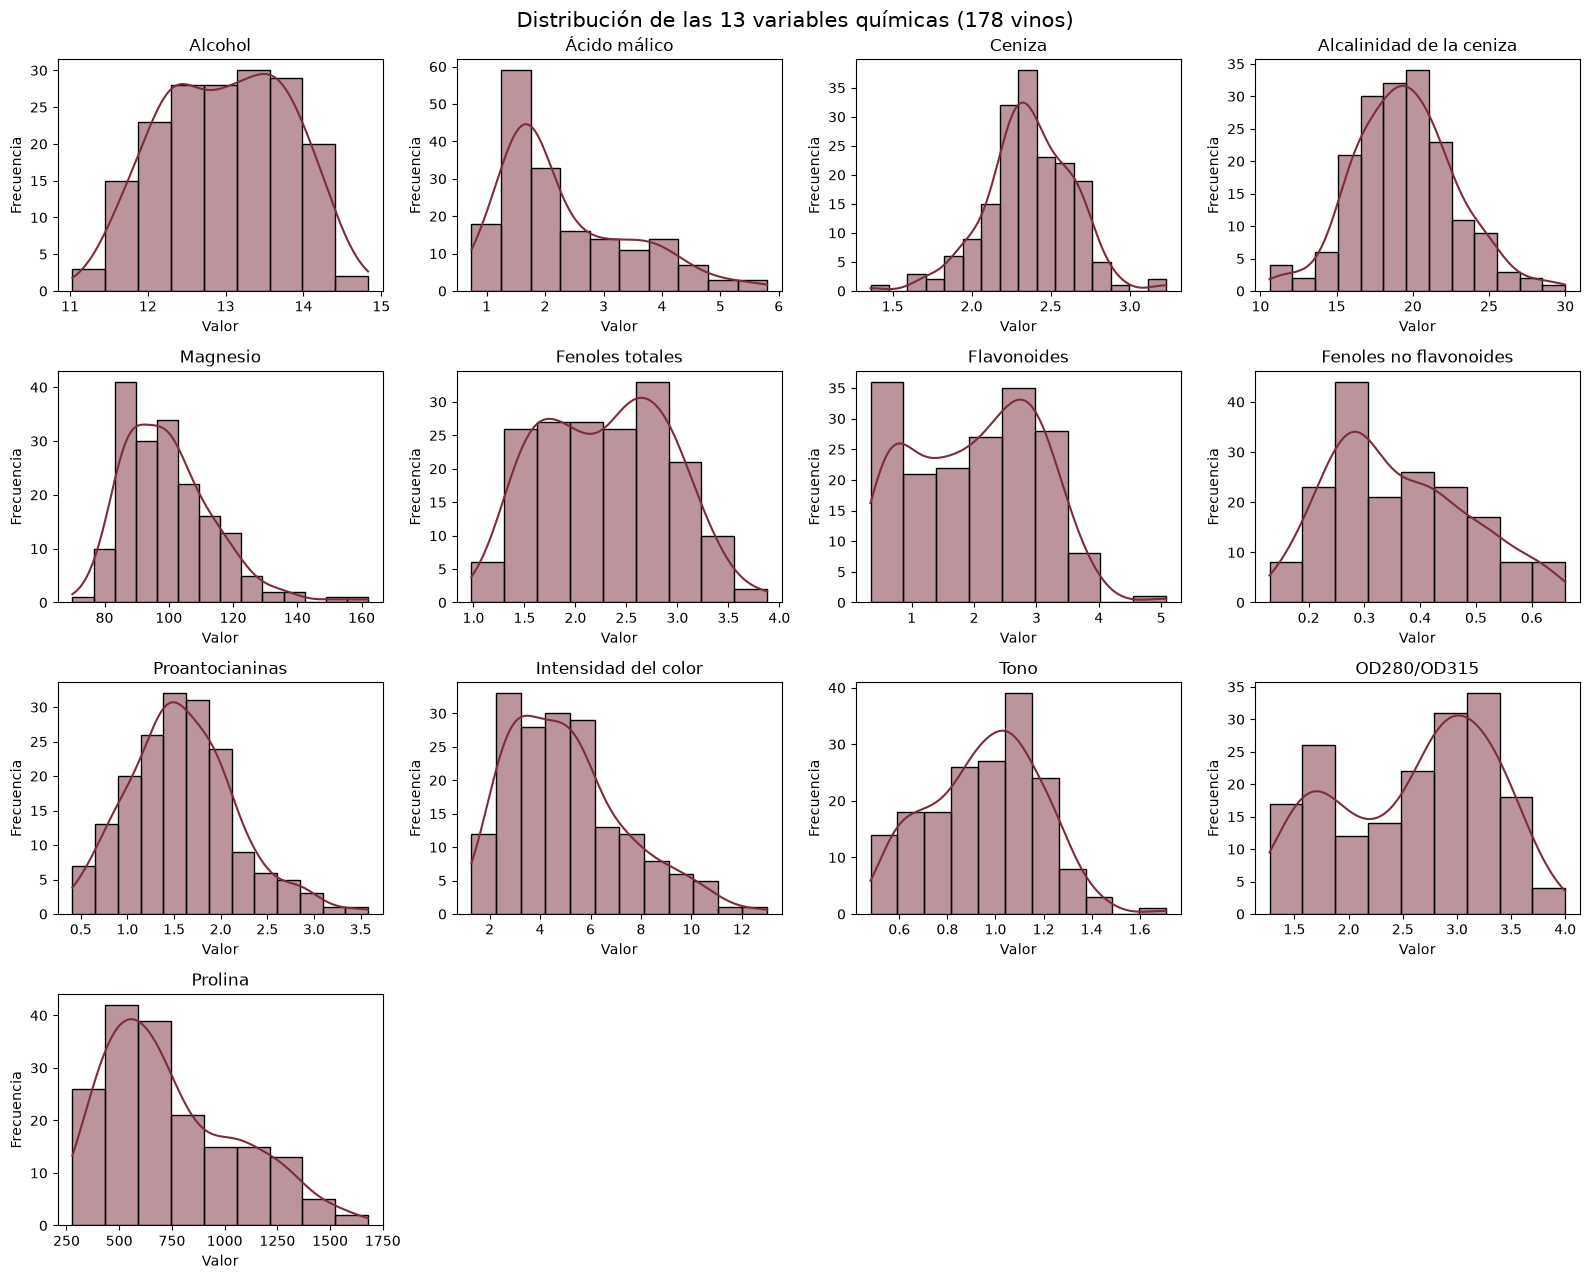

In [5]:
eda.graficar_histogramas(df);

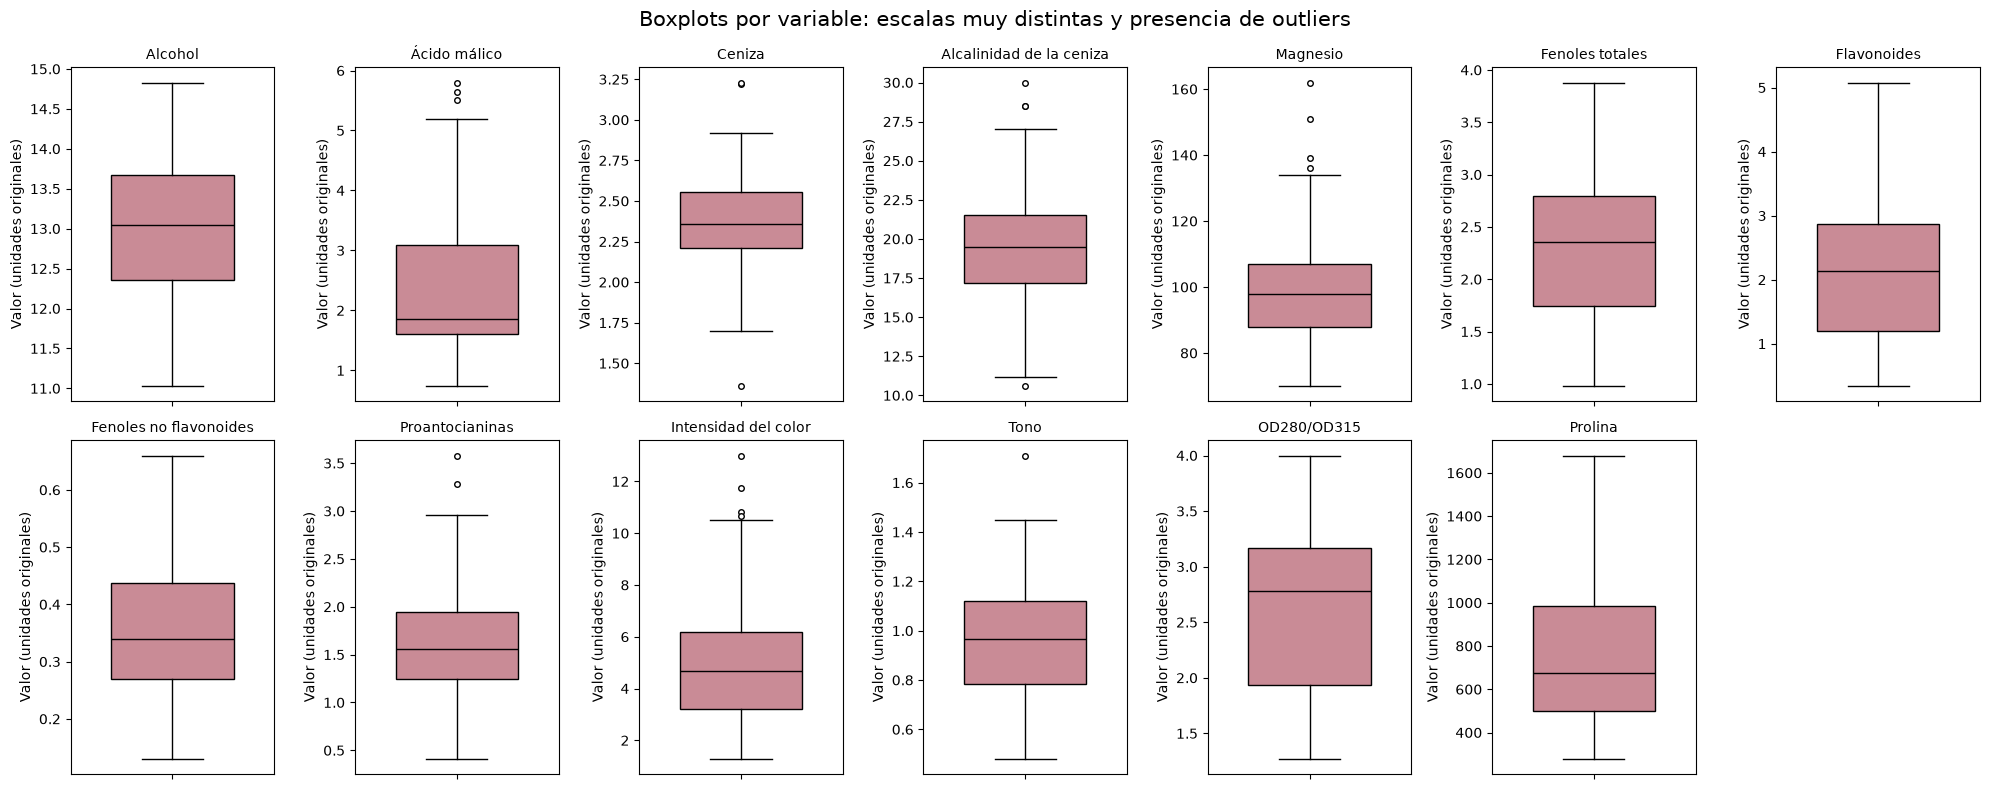

In [6]:
eda.graficar_boxplots(df);

In [7]:
eda.contar_outliers(df)

,outliers IQR,outliers |z|>3
Alcohol,0,0
Ácido málico,3,1
Ceniza,3,3
Alcalinidad de la ceniza,4,1
Magnesio,4,2
Fenoles totales,0,0
Flavonoides,0,1
Fenoles no flavonoides,0,0
Proantocianinas,2,1
Intensidad del color,4,1


**Outliers.** Por el criterio IQR (1,5·IQR) aparecen 17 vinos con al menos un valor atípico y, por |z| > 3, solo 10. Se concentran
en Ceniza, Magnesio, Alcalinidad de la ceniza, Intensidad del color y Ácido málico, y son **moderados** (no hay errores de carga
evidentes: son valores químicamente plausibles). La decisión sobre su tratamiento se toma en la sección 3.

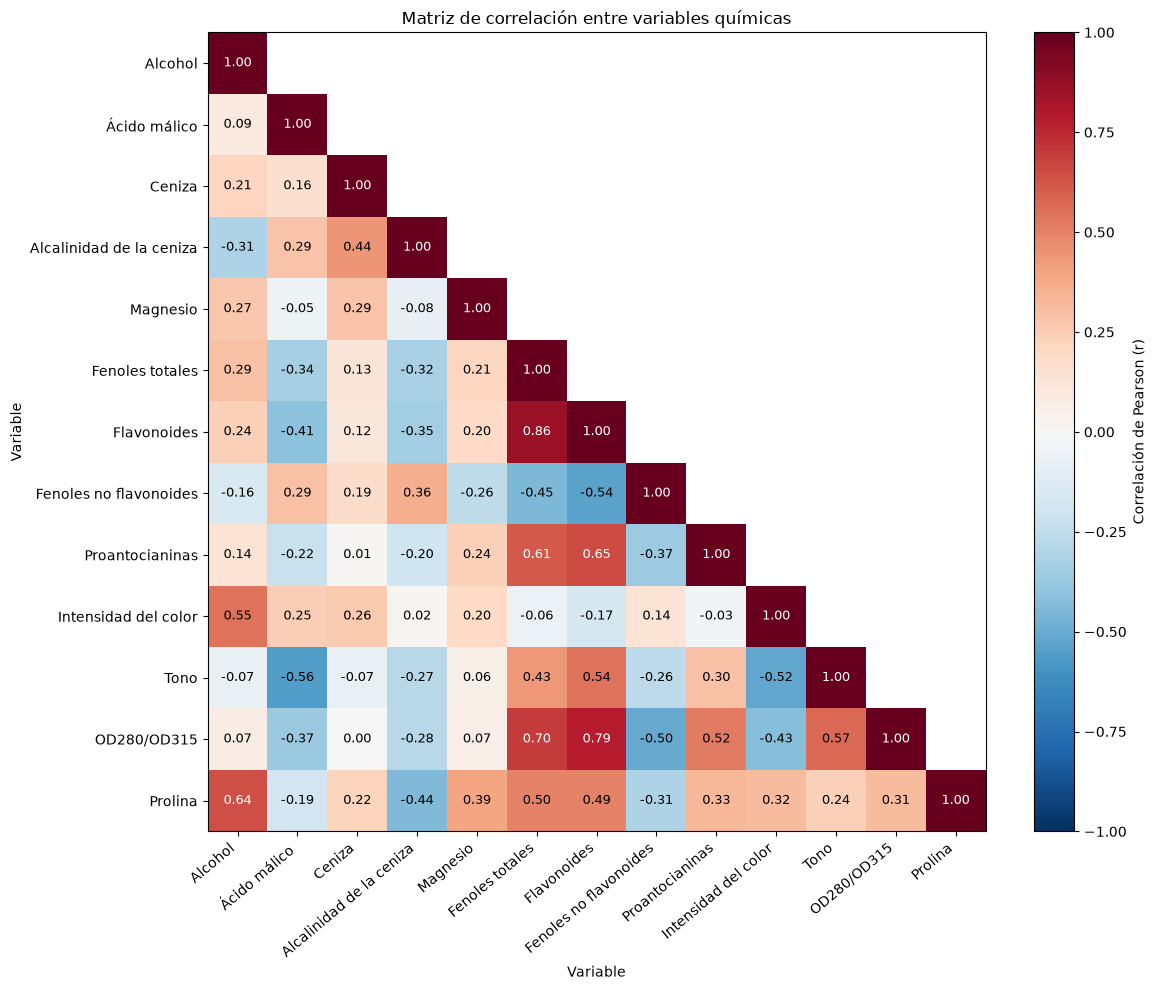

In [8]:
corr = eda.matriz_correlacion(df)
eda.graficar_correlacion(corr);

In [9]:
eda.correlaciones_fuertes(corr)

,variable 1,variable 2,r
0,Fenoles totales,Flavonoides,0.865
1,Flavonoides,OD280/OD315,0.787
2,Fenoles totales,OD280/OD315,0.700
3,Flavonoides,Proantocianinas,0.653
4,Alcohol,Prolina,0.644
5,Fenoles totales,Proantocianinas,0.612
6,Tono,OD280/OD315,0.565
7,Ácido málico,Tono,-0.561
8,Alcohol,Intensidad del color,0.546
9,Flavonoides,Tono,0.543


**Correlaciones.** Se confirma el bloque esperado de **polifenoles**: Fenoles totales–Flavonoides (r = 0,87),
Flavonoides–OD280/OD315 (0,79), Fenoles totales–OD280/OD315 (0,70) y Flavonoides–Proantocianinas (0,65). Alcohol y Prolina
también van juntos (0,64: ambos crecen con la madurez de la uva). Con signo negativo, **Tono e Intensidad del color** (r = −0,52):
los vinos de color más intenso tienden a tonos más teja; y Flavonoides con Fenoles no flavonoides (−0,54).
Consecuencia para el clustering: varias variables miden casi lo mismo (el eje "fenólico" pesa más en la distancia porque aparece
repetido); se conserva igual porque es información química legítima y el PCA posterior lo hará visible.

Variables con mayor coeficiente de variación: ['Flavonoides', 'Ácido málico', 'Intensidad del color', 'Prolina', 'Proantocianinas', 'Fenoles no flavonoides']


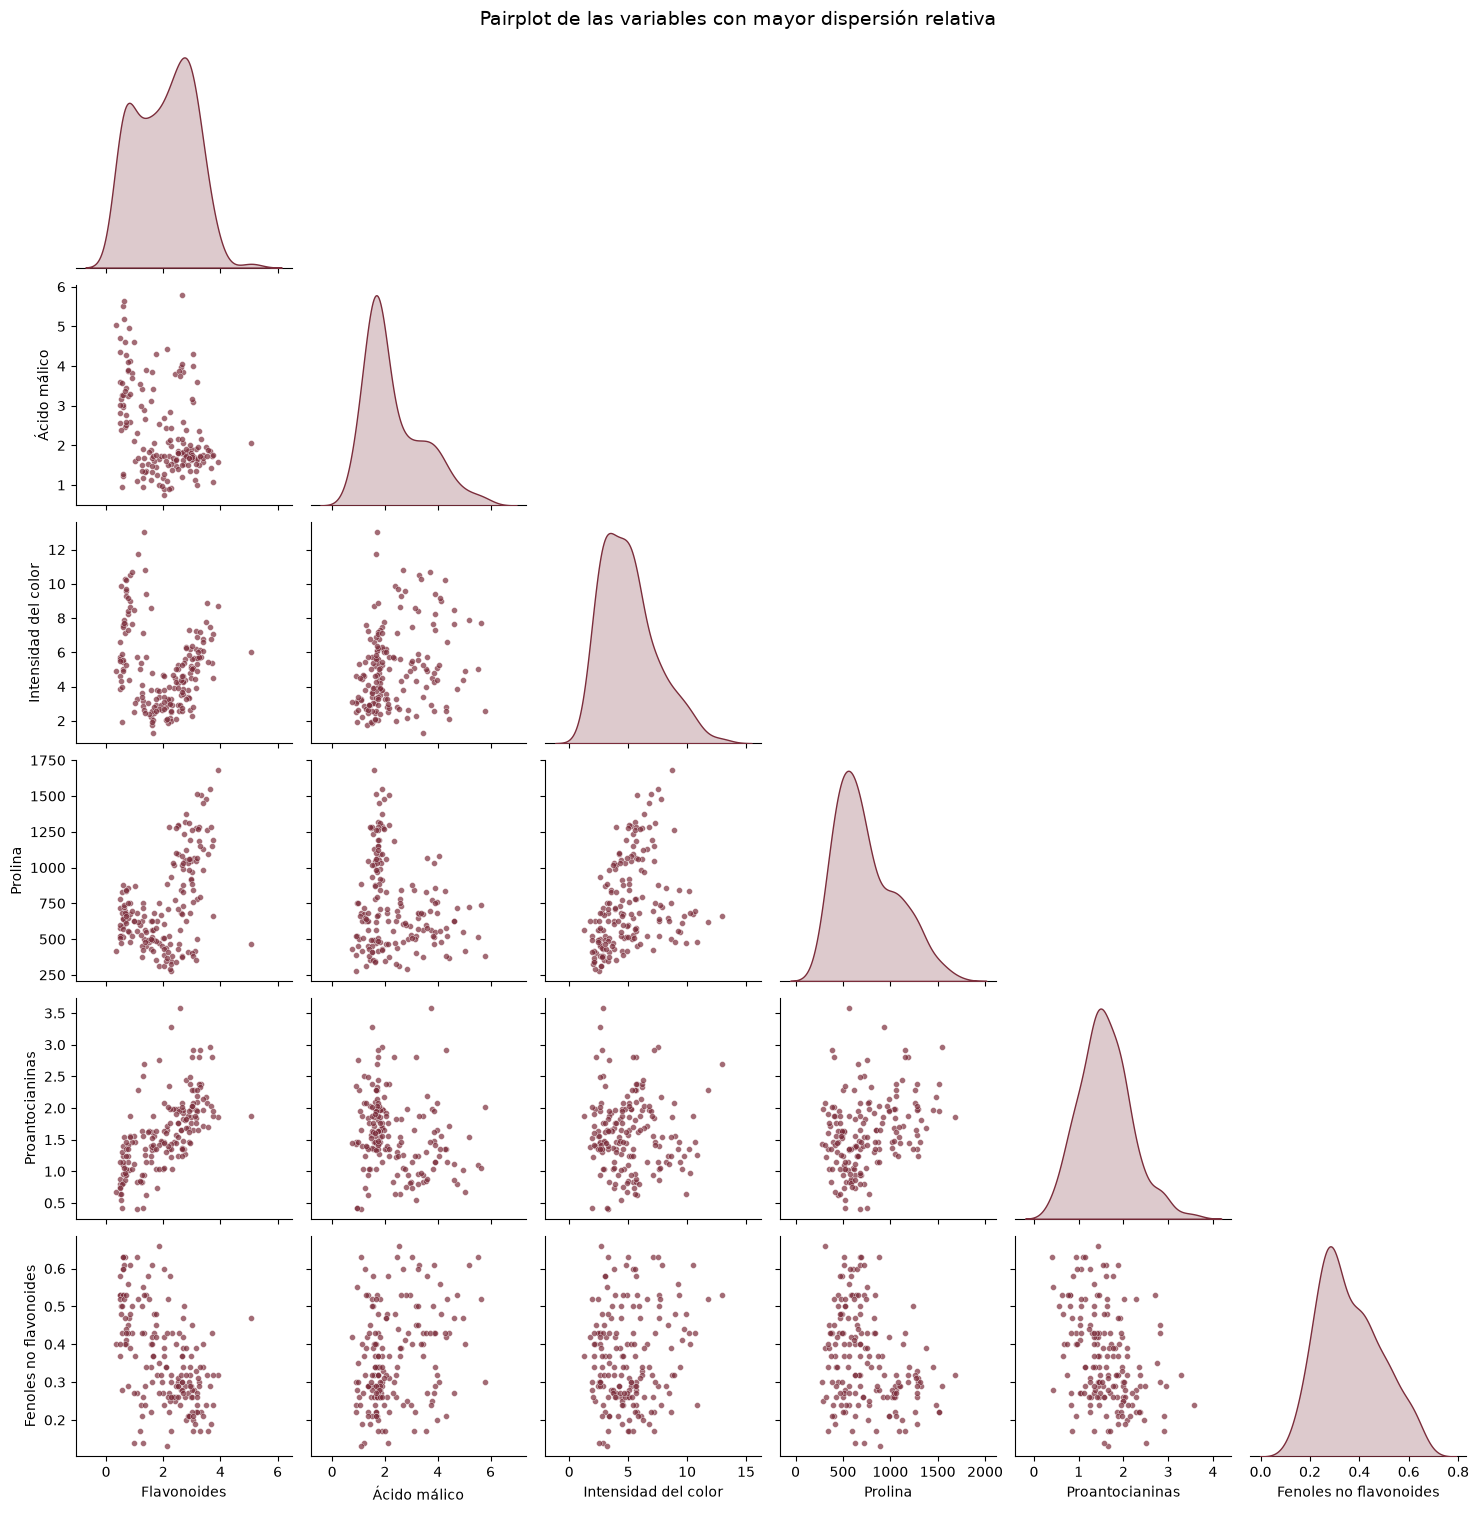

In [10]:
variables_pairplot = eda.seleccionar_variables_pairplot(df)
print("Variables con mayor coeficiente de variación:", variables_pairplot)
eda.graficar_pairplot(df, variables_pairplot);

Para el pairplot se eligieron las 6 variables de mayor **coeficiente de variación** (desvío/media, una medida de dispersión
relativa que no depende de las unidades ni de las etiquetas). En varios pares (por ejemplo Flavonoides vs. Intensidad del color o
Flavonoides vs. Prolina) ya se insinúan **tres nubes** de puntos.

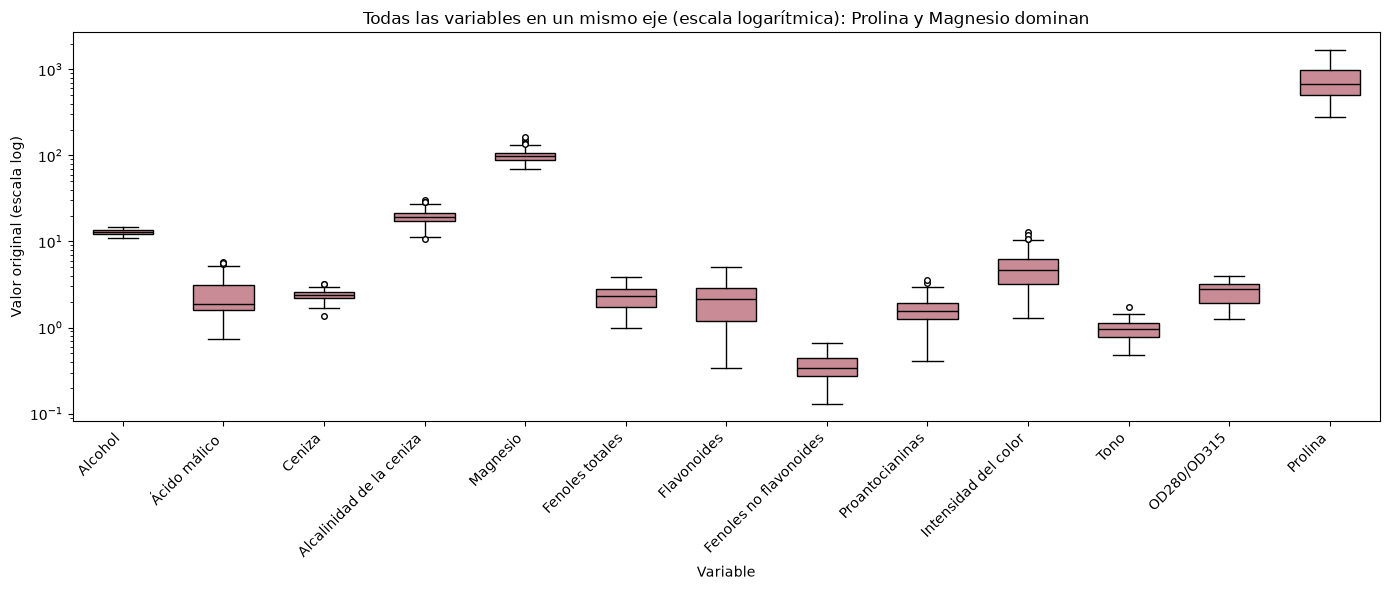

In [11]:
eda.graficar_boxplots_escala_comun(df);

In [12]:
eda.ejemplo_dominancia_escala(df, 0, 1)

,vino 0,vino 1,dif² sin escalar,% de la distancia² sin escalar,dif² escalado (z),% de la distancia² escalado
Alcohol,14.23,13.20,1.061e+00,1.085e-01,1.619,13.233
Ácido málico,1.71,1.78,4.900e-03,5.013e-04,0.004,0.032
Ceniza,2.43,2.14,8.410e-02,8.604e-03,1.124,9.186
Alcalinidad de la ceniza,15.60,11.20,1.936e+01,1.981e+00,1.746,14.271
Magnesio,127.00,100.00,7.290e+02,7.458e+01,3.594,29.379
Fenoles totales,2.80,2.65,2.250e-02,2.302e-03,0.058,0.472
Flavonoides,3.06,2.76,9.000e-02,9.207e-03,0.091,0.742
Fenoles no flavonoides,0.28,0.26,4.000e-04,4.092e-05,0.026,0.212
Proantocianinas,2.29,1.28,1.020e+00,1.044e-01,3.132,25.599
Intensidad del color,5.64,4.38,1.588e+00,1.624e-01,0.297,2.428


In [13]:
eda.participacion_varianza(df).to_frame()

,% varianza total
Prolina,9.977e+01
Magnesio,2.052e-01
Alcalinidad de la ceniza,1.122e-02
Intensidad del color,5.407e-03
Ácido málico,1.256e-03
Flavonoides,1.004e-03
Alcohol,6.631e-04
OD280/OD315,5.072e-04
Fenoles totales,3.941e-04
Proantocianinas,3.296e-04


### Conclusión obligatoria del EDA: las escalas son incomparables

- **Ejemplo numérico** (vinos 0 y 1): sin escalar, la distancia euclídea² vale 977,5 y el **97,6 %** proviene de Magnesio (74,6 %)
  y Prolina (23,0 %); diferencias químicamente relevantes como Proantocianinas (2,29 vs. 1,28, casi el doble) aportan un 0,1 %.
  Tras estandarizar, Proantocianinas pasa a explicar el 25,6 % y la contribución se reparte entre variables.
- **A nivel global**, Prolina concentra el **99,8 % de la varianza total** del dataset crudo. Como la inercia de K-Means es una
  suma de varianzas, sin escalar el algoritmo agruparía prácticamente por **una sola variable**.

⇒ Es imprescindible escalar antes de calcular distancias.

## 3. Preparación de los datos

### 3.1 Escalado: comparación de alternativas

Se comparan `StandardScaler` (z-score: media 0, desvío 1), `MinMaxScaler` (rango [0, 1]) y `RobustScaler` (mediana e IQR). Para
cada uno se mide cuán homogéneas quedan las escalas (cociente entre el mayor y el menor desvío) y la silueta de un K-Means
exploratorio con k = 3.

In [14]:
pp.comparar_escaladores(df)

,desvío mín.,desvío máx.,cociente máx/mín de desvíos,|valor| máximo,silueta K-Means k=3,tamaños
escalado,,,,,,
Sin escalar,0.124,314.022,2530.326,1680.000,0.571,"[69, 62, 47]"
StandardScaler (z-score),1.000,1.000,1.000,4.371,0.285,"[65, 62, 51]"
"MinMaxScaler [0, 1]",0.146,0.259,1.773,1.000,0.301,"[62, 61, 55]"
RobustScaler (mediana/IQR),0.574,0.815,1.419,3.368,0.265,"[65, 64, 49]"


**Decisión: `StandardScaler`.**

- Es el único que deja **todas las variables con exactamente la misma dispersión** (cociente de desvíos = 1). Con MinMax el cociente
  es 1,77 y con Robust 1,42: algunas variables seguirían pesando más que otras en la distancia por un artefacto del escalado.
- K-Means minimiza distancias euclídeas al cuadrado, es decir, **varianzas**: igualar las varianzas es lo que hace que cada variable
  tenga el mismo peso a priori. Es también la recomendación de la bibliografía (Guttag, MIT 6.0002: *z-scaling* para que las
  variables de rango grande no dominen).
- Las siluetas no son estrictamente comparables porque cada una se mide en su propio espacio; aun así, las tres variantes escaladas
  dan resultados similares (0,27–0,30) y tamaños parecidos, así que la elección **no es crítica** para la estructura encontrada.
- La silueta "sin escalar" (0,57) es engañosamente alta: mide la separación en un espacio que es, en la práctica, unidimensional
  (Prolina). Se analiza en 4.3.
- `RobustScaler` sería preferible si los outliers fueran severos (usa mediana e IQR, que no se distorsionan por extremos); no es el
  caso aquí (ver 3.2).

### 3.2 Outliers: se conservan

Con solo 178 muestras, eliminar los 17 vinos marcados por IQR descartaría casi el 10 % de los datos, y sus valores son plausibles
químicamente. **Se conservan** y se verifica su impacto en la sección 4.3 comparando contra una versión *winsorizada* (recortada a
[Q1 − 1,5·IQR, Q3 + 1,5·IQR]), que queda documentada como alternativa.

### 3.3 Medida de distancia

- **K-Means usa distancia euclídea** y no es una elección libre: el paso de actualización toma el centroide como la **media** del
  cluster, y la media es justamente el punto que minimiza la suma de distancias euclídeas **al cuadrado**. Con Manhattan el punto
  óptimo sería la mediana (K-Medianas) y con Chebyshev no hay un centro con fórmula cerrada; por eso `sklearn.cluster.KMeans` no
  ofrece un parámetro de métrica.
- En el **clustering jerárquico** sí se puede cambiar: se incluye una corrida con **Manhattan** (`metric='manhattan'`) y linkage
  medio y completo como contraste (sección 4.4). Chebyshev, al quedarse solo con la mayor diferencia, descartaría la información de
  12 de las 13 variables en cada comparación, lo que no resulta razonable en un perfil químico multivariado.

In [15]:
df_esc, escalador = pp.escalar(df)
X = df_esc.to_numpy()
print("Guardado en:", pp.guardar_procesado(df_esc))
df_esc.describe().loc[["mean", "std"]].round(3)

Guardado en: C:\Antigravity\CAECE\caece_aprendizaje_artificial_u2\data\processed\vinos_escalado.csv


,Alcohol,Ácido málico,Ceniza,Alcalinidad de la ceniza,Magnesio,Fenoles totales,Flavonoides,Fenoles no flavonoides,Proantocianinas,Intensidad del color,Tono,OD280/OD315,Prolina
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003


## 4. Modelado

### 4.1 Elección de k

No se asume k = 3 de entrada (aunque el dominio sugiere tres variedades de uva): primero se deja que los datos "hablen" con cinco
criterios independientes y recién después se confronta con el conocimiento del dominio.

In [16]:
tabla_k = cl.evaluar_rango_k(X, range(1, 11))
tabla_k

,inercia (WCSS),reducción % vs k-1,tamaño mín.,tamaño máx.,silueta,Calinski-Harabasz,Davies-Bouldin
k,,,,,,,
1,2314.000,NaN,178,178,NaN,NaN,NaN
2,1658.759,28.316,87,91,0.259,69.523,1.526
3,1277.928,22.959,51,65,0.285,70.940,1.389
4,1175.428,8.021,29,55,0.260,56.181,1.797
5,1109.513,5.608,26,59,0.202,46.952,1.808
6,1046.002,5.724,5,53,0.237,41.701,1.554
7,981.595,6.157,3,54,0.204,38.686,1.661
8,935.201,4.726,3,39,0.157,35.805,1.741
9,889.893,4.845,4,34,0.150,33.807,1.708


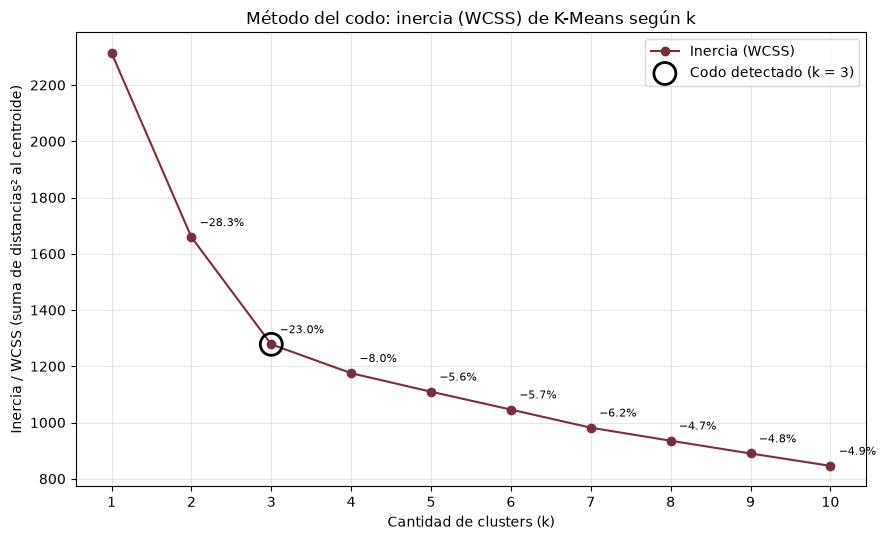

In [17]:
k_codo = cl.detectar_codo(tabla_k["inercia (WCSS)"])
cl.graficar_codo(tabla_k, k_codo);

**Método del codo.** La inercia (WCSS, suma de distancias al cuadrado de cada vino a su centroide) cae 28,3 % al pasar de 1 a 2
clusters y 23,0 % de 2 a 3; a partir de allí la curva **se plancha**: 8,0 % de 3 a 4 y luego entre 4,7 % y 6,2 % por cada cluster
extra. El codo detectado automáticamente (punto más alejado de la recta que une los extremos de la curva normalizada) es **k = 3**.

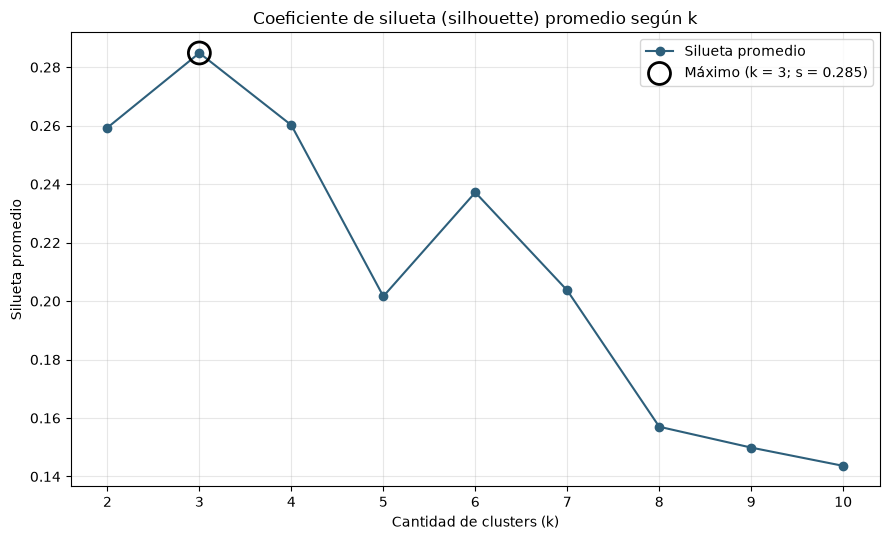

In [18]:
cl.graficar_silueta_promedio(tabla_k, int(tabla_k["silueta"].idxmax()));

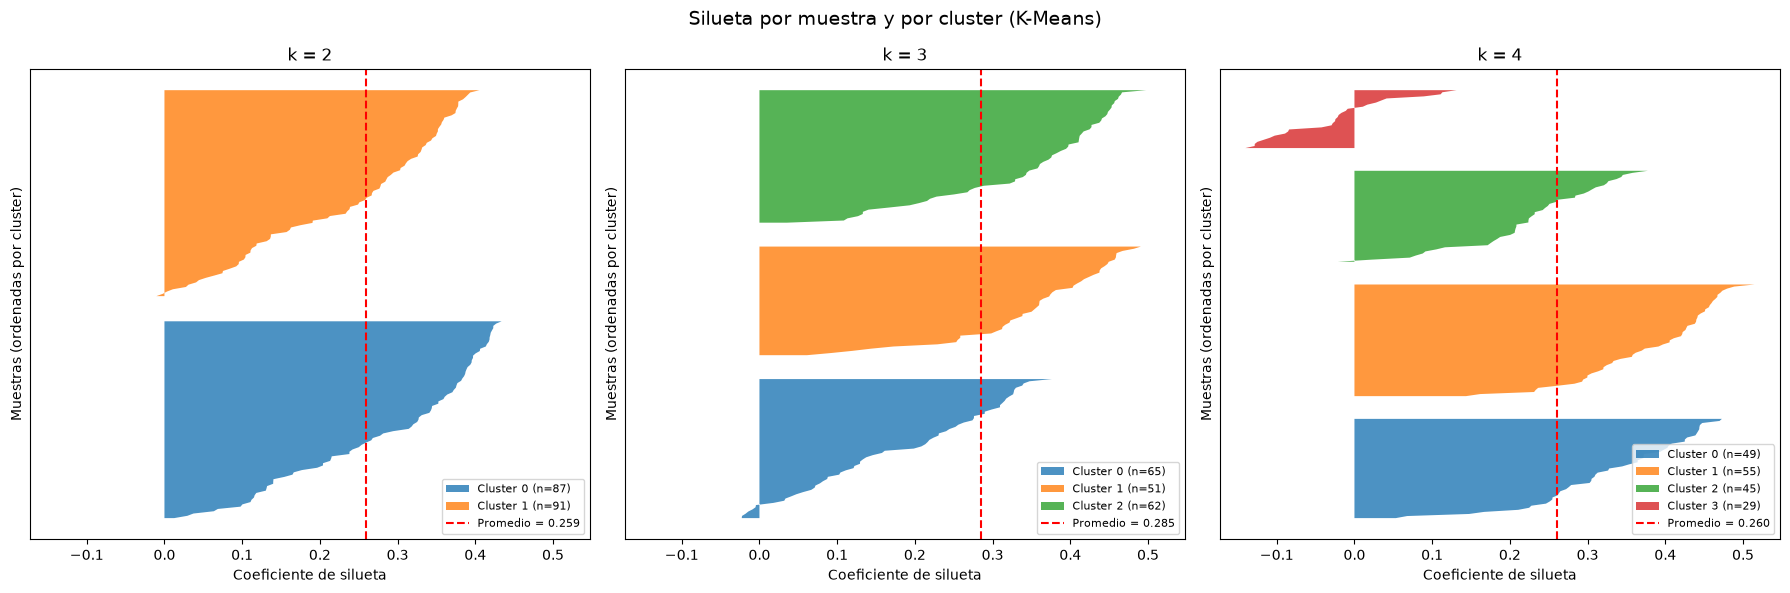

In [19]:
cl.graficar_siluetas_por_cluster(X, [2, 3, 4]);

**Coeficiente de silueta (*silhouette*).** Para cada vino compara la distancia media a su propio cluster (*a*) con la del cluster
vecino más cercano (*b*): s = (b − a) / max(a, b), entre −1 y 1. El promedio es máximo en **k = 3 (0,285)**, frente a 0,259 en
k = 2 y 0,260 en k = 4. En el gráfico por cluster, con k = 3 los tres grupos superan el promedio en buena parte de sus miembros y
casi no hay valores negativos; con k = 4 aparece un cluster pequeño y débil (siluetas bajas), señal de que se está partiendo un
grupo natural. Un valor de 0,28 indica estructura **moderada** (clusters con cierto solapamiento en 13 dimensiones), algo esperable
en datos químicos reales.

**Calinski-Harabasz y Davies-Bouldin** (tabla anterior): CH (dispersión entre / dentro, mayor es mejor) es máximo en k = 3 (70,9) y
DB (similitud promedio de cada cluster con su más parecido, menor es mejor) es mínimo en k = 3 (1,389).

In [20]:
Z_ward = cl.calcular_linkage(X, "ward")
saltos = cl.saltos_dendrograma(Z_ward)
saltos

,altura inferior,altura superior,salto,umbral de corte
k,,,,
2,27.652,35.402,7.750,31.527
3,12.567,27.652,15.085,20.110
4,12.231,12.567,0.336,12.399
5,11.722,12.231,0.509,11.976
6,11.376,11.722,0.346,11.549
7,10.399,11.376,0.977,10.887
8,10.155,10.399,0.244,10.277
9,8.291,10.155,1.864,9.223
10,8.253,8.291,0.038,8.272


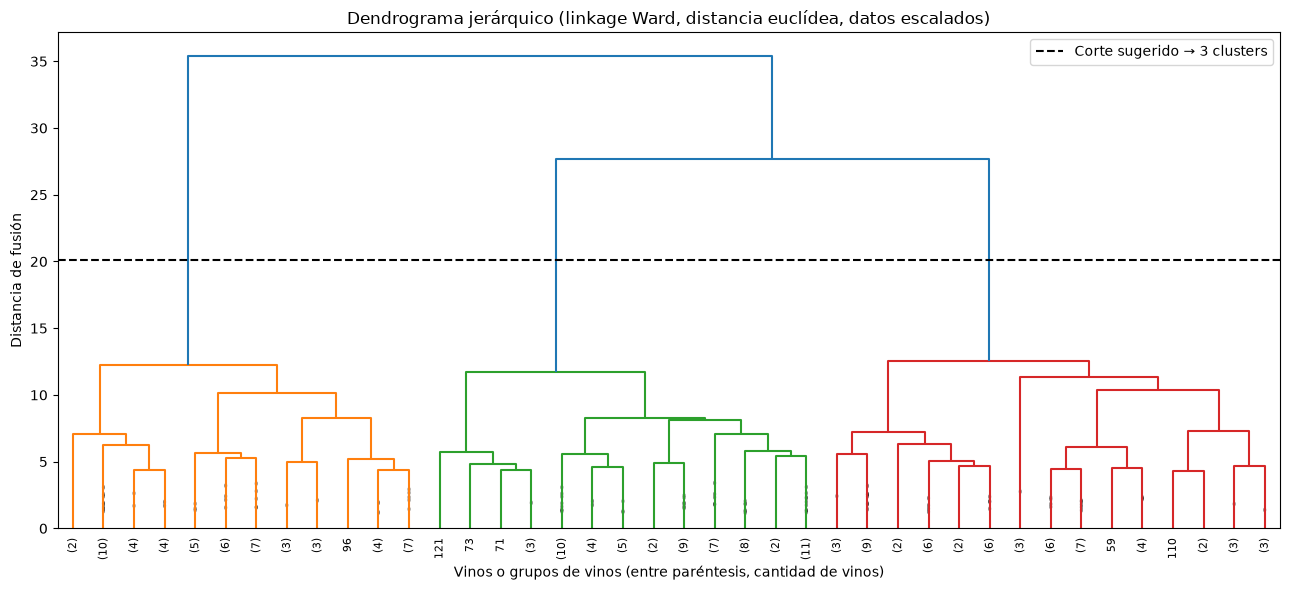

In [21]:
cl.graficar_dendrograma(Z_ward, saltos.loc[3, "umbral de corte"], 3,
                        "Dendrograma jerárquico (linkage Ward, distancia euclídea, datos escalados)");

**Dendrograma (Ward).** Las dos últimas fusiones ocurren a distancias 27,7 y 35,4, mientras que la anterior sucede a 12,6. El mayor
salto de distancia de fusión (15,1) se da al pasar de 3 a 2 clusters: cortar el árbol entre 12,6 y 27,7 (línea punteada) deja
**tres ramas** bien diferenciadas. Por debajo del corte, los saltos son pequeños (< 2), es decir, no hay otra partición "natural".

In [22]:
resumen_k = cl.resumen_eleccion_k(tabla_k, k_codo, saltos)
resumen_k

,k sugerido,evidencia
criterio,,
Método del codo (WCSS),3,reducción de 23.0% al pasar a k=3 y de 8.0% al...
Silueta promedio (máx.),3,s = 0.285
Calinski-Harabasz (máx.),3,CH = 70.9
Davies-Bouldin (mín.),3,DB = 1.389
Mayor salto del dendrograma (Ward),3,salto = 15.08


**Decisión: k = 3.** Los cinco criterios coinciden (no hay desacuerdo que resolver), los tamaños son homogéneos (51 a 65 vinos,
frente a k ≥ 6 donde aparecen clusters de 3–5 vinos que no sirven) y el resultado es **consistente con el conocimiento del
dominio** (tres variedades de uva). Que el dominio y los datos coincidan refuerza la decisión, pero no la reemplaza: se llegó a
k = 3 sin usar las etiquetas.

In [23]:
k = int(resumen_k["k sugerido"].mode()[0])
k

3

### 4.2 K-Means final

`KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=300, random_state=42)`

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `n_clusters` | 3 | Resultado de 4.1 (consenso de 5 criterios). |
| `init` | `'k-means++'` | En lugar de elegir los k centroides iniciales totalmente al azar, elige el primero al azar y los siguientes con probabilidad proporcional a la distancia² al centroide más cercano ya elegido: los centroides iniciales quedan **repartidos** en el espacio. Converge más rápido y reduce el riesgo de mínimos locales pobres (idea que Guttag propone como "distribuir los centroides iniciales"). |
| `n_init` | 10 | Corre el algoritmo 10 veces con inicializaciones distintas y se queda con la de **menor inercia**: mitigación directa de la limitación de la inicialización aleatoria. |
| `max_iter` | 300 | Tope de iteraciones por corrida (asignar → recalcular medias). En la práctica converge en muy pocas; el tope evita gastar recursos si no converge. |
| `random_state` | 42 | Semilla fija para que los resultados sean **reproducibles**. |

In [24]:
kmeans = cl.crear_kmeans(k).fit(X)
etiquetas_km = kmeans.labels_
print(f"Iteraciones hasta converger: {kmeans.n_iter_} | Inercia: {kmeans.inertia_:.2f}")

Iteraciones hasta converger: 7 | Inercia: 1277.93


### 4.3 Estabilidad y sanidad

**Estabilidad entre corridas.** Se corre K-Means con 10 semillas distintas y se mide el acuerdo entre cada par de soluciones con
el **Índice de Rand Ajustado (ARI)**: 1 = particiones idénticas (sin importar la numeración de los clusters), ≈ 0 = acuerdo al
azar. Como contraste se repite con `init='random'` y una única inicialización (el K-Means "de manual").

In [25]:
estabilidad = pd.DataFrame([cl.estabilidad_semillas(X, k),
                            cl.estabilidad_semillas(X, k, n_init=1, init="random")]).set_index("configuración")
estabilidad

,corridas,ARI medio,ARI mínimo,inercia mín.,inercia máx.,soluciones distintas
configuración,,,,,,
"init='k-means++', n_init=10",10,0.996,0.982,1277.928,1278.761,2
"init='random', n_init=1",10,0.959,0.865,1277.928,1282.464,5


Con la configuración elegida el **ARI medio es 0,996 y el mínimo 0,982** (> 0,9): de 10 semillas salen solo 2 soluciones, que
difieren en un par de vinos fronterizos (inercias 1277,9 vs. 1278,8). Con inicialización aleatoria simple aparecen 5 soluciones
distintas y el ARI mínimo cae a 0,865: es la **evidencia empírica** de la limitación de la inicialización aleatoria que plantea la
cátedra, y de por qué `k-means++` + `n_init=10` la mitigan.

In [26]:
cl.tamanos_clusters(etiquetas_km)

,vinos,%
cluster,,
0,65,36.517
1,51,28.652
2,62,34.831


**Tamaños.** 51, 62 y 65 vinos (28,7 % – 36,5 %): la partición es razonablemente homogénea, lejos del caso patológico "un cluster
de 2 y otro de 170".

**K-Means sin escalar.** Se repite el modelo sobre los datos crudos para mostrar qué se habría obtenido sin la decisión de escalado:

In [27]:
tabla_sin_escalar, dominancia = cl.comparar_sin_escalar(df, X, etiquetas_km, k)
tabla_sin_escalar

,tamaños,silueta (espacio original),silueta (espacio escalado),ARI vs. K-Means escalado
K-Means SIN escalar,"[69, 62, 47]",0.571,0.108,0.354
K-Means CON StandardScaler,"[65, 62, 51]",0.194,0.285,1.000


In [28]:
dominancia.to_frame()

,% de la separación entre clusters (sin escalar)
Prolina,9.995e+01
Magnesio,4.111e-02
Alcalinidad de la ceniza,2.750e-03
Intensidad del color,6.986e-04
Flavonoides,4.136e-04
Alcohol,3.077e-04
Fenoles totales,1.377e-04
OD280/OD315,1.092e-04
Ácido málico,8.610e-05
Proantocianinas,4.340e-05


Sin escalar, **Prolina explica el 99,95 % de la separación entre clusters**: el modelo simplemente corta la Prolina en tres tramos.
Por eso su silueta en el espacio original es alta (0,57) —es la silueta de un problema casi unidimensional— pero, medida en el
espacio escalado (donde las 13 variables cuentan), cae a 0,11. El acuerdo con la solución escalada es bajo (ARI = 0,35). Es el mismo
fenómeno que muestra Guttag con el ejemplo de pacientes: sin *z-scaling* el clustering no captura la estructura real.

**Impacto de los outliers.** Se repite el K-Means sobre los datos winsorizados:

In [29]:
df_wins_esc, _ = pp.escalar(pp.recortar_outliers_iqr(df))
cl.impacto_outliers(df_wins_esc.to_numpy(), etiquetas_km, k)

{'ARI vs. solución con outliers': 1.0,
 'vinos que cambian de cluster': 0,
 'tamaños con winsorización': [65, 62, 51]}

La partición es **idéntica** (ARI = 1, ningún vino cambia de cluster): los outliers moderados no influyen en el resultado, lo que
valida la decisión de conservarlos.

### 4.4 Modelo alternativo: clustering jerárquico aglomerativo

Se ajusta `AgglomerativeClustering` con k = 3 y distintos criterios de enlace (*linkage*): **Ward** (une los dos grupos que menos
aumentan la varianza intra-cluster, el análogo jerárquico de K-Means), **completo** (distancia entre los miembros más lejanos),
**medio** (promedio de todas las distancias) y **simple** (miembros más cercanos), con distancia euclídea, más linkage medio y
completo con **Manhattan** como contraste de métrica.

In [30]:
tabla_jer, etiquetas_jer = cl.comparar_jerarquicos(X, k, etiquetas_km)
tabla_jer

,linkage,métrica,silueta (euclídea),silueta (métrica propia),tamaños,ARI vs. K-Means
modelo,,,,,,
K-Means (k-means++),—,euclidean,0.285,0.285,"[65, 62, 51]",1.000
Jerárquico ward (euclidean),ward,euclidean,0.277,0.277,"[64, 58, 56]",0.853
Jerárquico complete (euclidean),complete,euclidean,0.204,0.204,"[69, 58, 51]",0.596
Jerárquico average (euclidean),average,euclidean,0.158,0.158,"[174, 3, 1]",-0.002
Jerárquico single (euclidean),single,euclidean,0.183,0.183,"[174, 3, 1]",-0.003
Jerárquico average (manhattan),average,manhattan,0.252,0.277,"[126, 51, 1]",0.487
Jerárquico complete (manhattan),complete,manhattan,0.190,0.202,"[97, 52, 29]",0.518


In [31]:
et_km_ord, _ = it.ordenar_clusters(etiquetas_km, df)
et_ward_ord, _ = it.ordenar_clusters(etiquetas_jer["Jerárquico ward (euclidean)"], df)
cl.tabla_contingencia(et_km_ord, et_ward_ord, "K-Means", "Jerárquico Ward")

Jerárquico Ward,1,2,3,Total
K-Means,,,,
1,61,0,1,62
2,0,51,0,51
3,3,5,57,65
Total,64,56,58,178


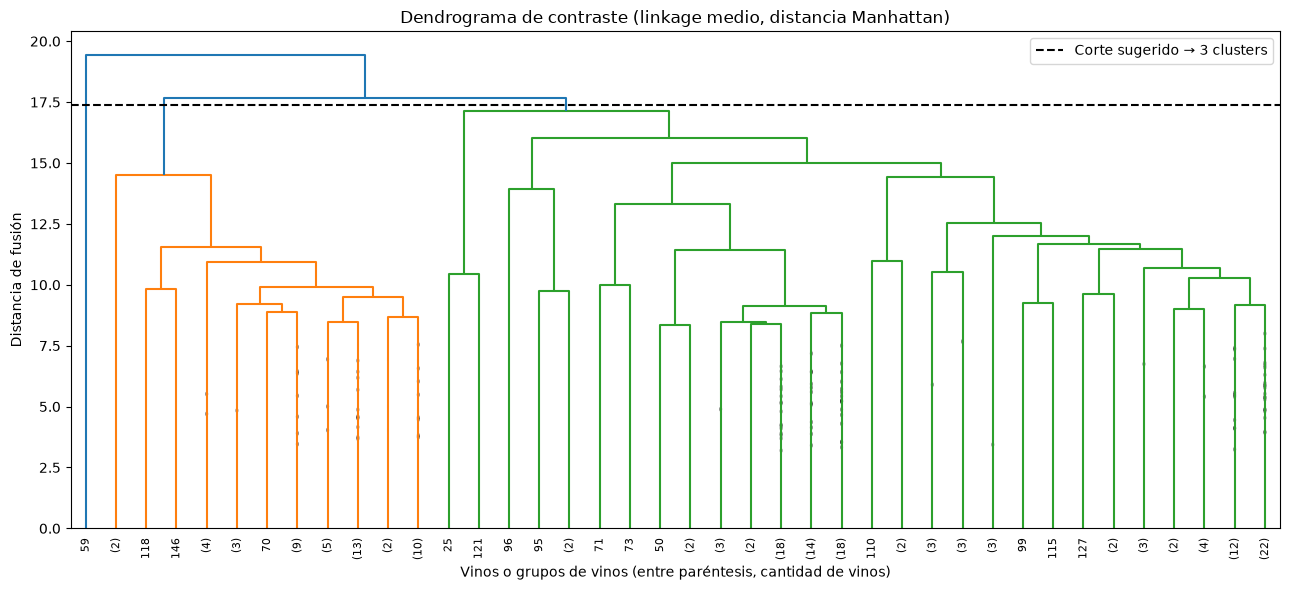

In [32]:
Z_man = cl.calcular_linkage(X, "average", "cityblock")
cl.graficar_dendrograma(Z_man, cl.saltos_dendrograma(Z_man).loc[k, "umbral de corte"], k,
                        "Dendrograma de contraste (linkage medio, distancia Manhattan)");

**Lectura de la comparación.**

- **Ward** reproduce casi la misma partición que K-Means (ARI = 0,85; silueta 0,277 vs. 0,285): en la tabla de contingencia
  coinciden 169 de 178 vinos y las diferencias son vinos fronterizos del cluster 3. Que dos algoritmos con lógicas distintas
  (particional vs. jerárquico) lleguen a lo mismo es evidencia de que la estructura es **real** y no un artefacto del método.
- **Simple y medio (euclídea)** fallan: producen tamaños 174/3/1. El enlace simple sufre el **efecto cadena** (une grupos a través de
  puntos intermedios) y ambos terminan aislando unos pocos outliers en lugar de separar grupos: justo el caso de "un cluster de 170 y
  otro de 2" que la cátedra advierte que no sirve.
- **Completo** mejora (tamaños 69/58/51) pero con peor silueta (0,20) y ARI 0,60.
- **Manhattan** (medio y completo) tampoco supera a Ward/K-Means (siluetas 0,25 y 0,19 con euclídea; 126/51/1 y 97/52/29). Cambiar la
  métrica no aporta aquí: las variables ya están estandarizadas y no hay motivo de dominio para preferir sumar diferencias absolutas.

**Ventajas y costos.** El jerárquico no necesita fijar k a priori (se elige cortando el dendrograma, como se hizo en 4.1) y es
determinístico, pero su costo es al menos O(n²) en memoria y tiempo (O(n³) en la versión ingenua), frente a O(k·n·d) por iteración
de K-Means, y sus decisiones son *greedy* (una fusión no se deshace).

**Modelo final: K-Means (k = 3).** Tiene la mejor silueta, CH y DB; es estable entre semillas; da centroides directamente
interpretables (necesarios para nombrar los tipos) y escala a más datos. Ward queda como **validación cruzada** del resultado.

## 5. Evaluación e interpretación

### 5.1 Orden determinístico de los clusters

La numeración que devuelve K-Means (0, 1, 2) depende de la inicialización. Para que los resultados sean reproducibles y los nombres
no dependan del azar, los clusters se **renumeran 1..3 por Prolina media descendente** (la variable que más separa los grupos en
la literatura del dataset).

In [33]:
etiquetas, mapeo = it.ordenar_clusters(etiquetas_km, df)
print("Mapeo ID original de K-Means → ID ordenado:", mapeo)
centroides = it.centroides_originales(kmeans, escalador, mapeo, df.columns)
centroides.round(2)

Mapeo ID original de K-Means → ID ordenado: {2: 1, 1: 2, 0: 3}


,Alcohol,Ácido málico,Ceniza,Alcalinidad de la ceniza,Magnesio,Fenoles totales,Flavonoides,Fenoles no flavonoides,Proantocianinas,Intensidad del color,Tono,OD280/OD315,Prolina
cluster,,,,,,,,,,,,,
1,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23
2,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
3,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17


La tabla anterior son los **centroides des-escalados a unidades originales** (`scaler.inverse_transform`): la "receta química"
promedio de cada grupo.

In [34]:
it.comparar_con_media_global(df, etiquetas).round(2)

,Cluster 1,Cluster 2,Cluster 3,Media global
Alcohol,13.68,13.13,12.25,13.00
Ácido málico,2.00,3.31,1.90,2.34
Ceniza,2.47,2.42,2.23,2.37
Alcalinidad de la ceniza,17.46,21.24,20.06,19.49
Magnesio,107.97,98.67,92.74,99.74
Fenoles totales,2.85,1.68,2.25,2.30
Flavonoides,3.00,0.82,2.05,2.03
Fenoles no flavonoides,0.29,0.45,0.36,0.36
Proantocianinas,1.92,1.15,1.62,1.59
Intensidad del color,5.45,7.23,2.97,5.06


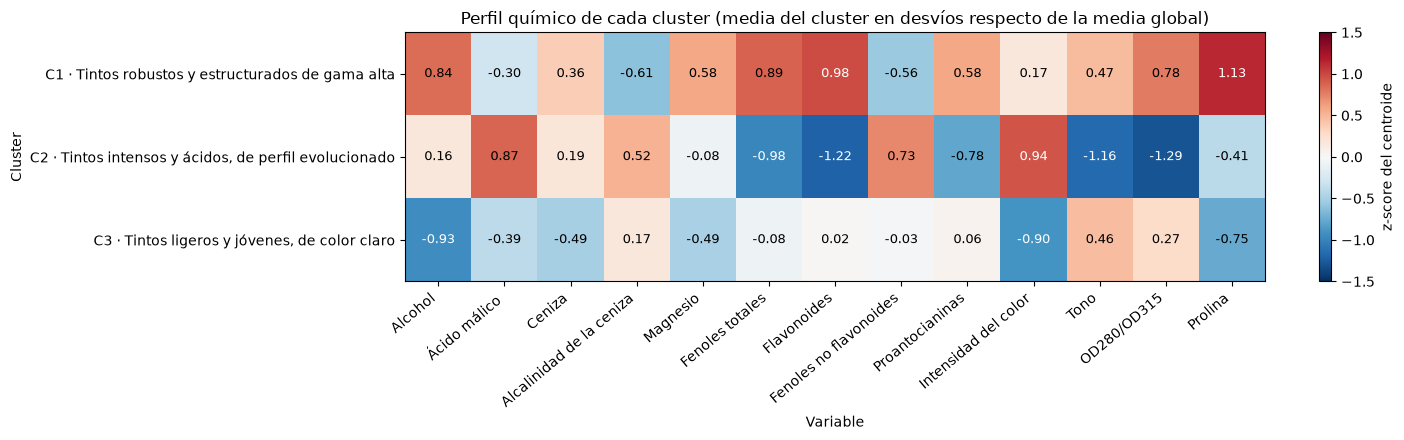

In [35]:
perfiles = it.perfiles_zscore(df_esc, etiquetas)
arquetipos = it.identificar_tipos(perfiles)
fichas = it.fichas_tipos(centroides, perfiles, df.mean(), arquetipos)
nombres = {c: f["nombre"] for c, f in fichas.items()}
it.graficar_heatmap_perfiles(perfiles, nombres);

El heatmap expresa cada centroide en **z-score** (cuántos desvíos se aleja de la media global): rojo = por encima, azul = por debajo.
Se leen tres perfiles muy nítidos:

- **C1**: rojo en Prolina (+1,13), Flavonoides (+0,98), Fenoles totales (+0,89), Alcohol (+0,84) y OD280/OD315 (+0,78).
- **C2**: azul intenso en OD280/OD315 (−1,29), Flavonoides (−1,22), Tono (−1,16) y Fenoles totales (−0,98); rojo en Intensidad del
  color (+0,94), Ácido málico (+0,87) y Fenoles no flavonoides (+0,73).
- **C3**: azul en Alcohol (−0,93), Intensidad del color (−0,90) y Prolina (−0,75); el resto cerca de la media.

(Los nombres del eje vertical se justifican en la sección 6.)

In [36]:
ranking = it.ranking_discriminantes(df_esc, etiquetas)
ranking

,ranking,F de ANOVA,p-valor,varianza de medias (z)
variable,,,,
Flavonoides,1,271.590,2.215e-54,1.209
OD280/OD315,2,221.528,1.124e-48,1.166
Prolina,3,200.312,5.671e-46,1.000
Alcohol,4,113.166,2.879e-32,0.790
Intensidad del color,5,111.923,4.959e-32,0.857
Fenoles totales,6,106.883,4.657e-31,0.869
Tono,7,104.747,1.225e-30,0.889
Ácido málico,8,38.669,1.237e-14,0.499
Proantocianinas,9,36.212,6.911e-14,0.471


**Variables más discriminantes** (F de ANOVA de un factor: varianza entre clusters sobre varianza dentro): Flavonoides (F = 272),
OD280/OD315 (222), Prolina (200), Alcohol (113), Intensidad del color (112) y Fenoles totales (107). Todas tienen p-valor ≈ 0 (en
rigor, el test es optimista porque los grupos se construyeron con esas mismas variables; se usa como **ranking**, no como prueba de
hipótesis). Ceniza, Magnesio y Alcalinidad de la ceniza son las que menos separan.

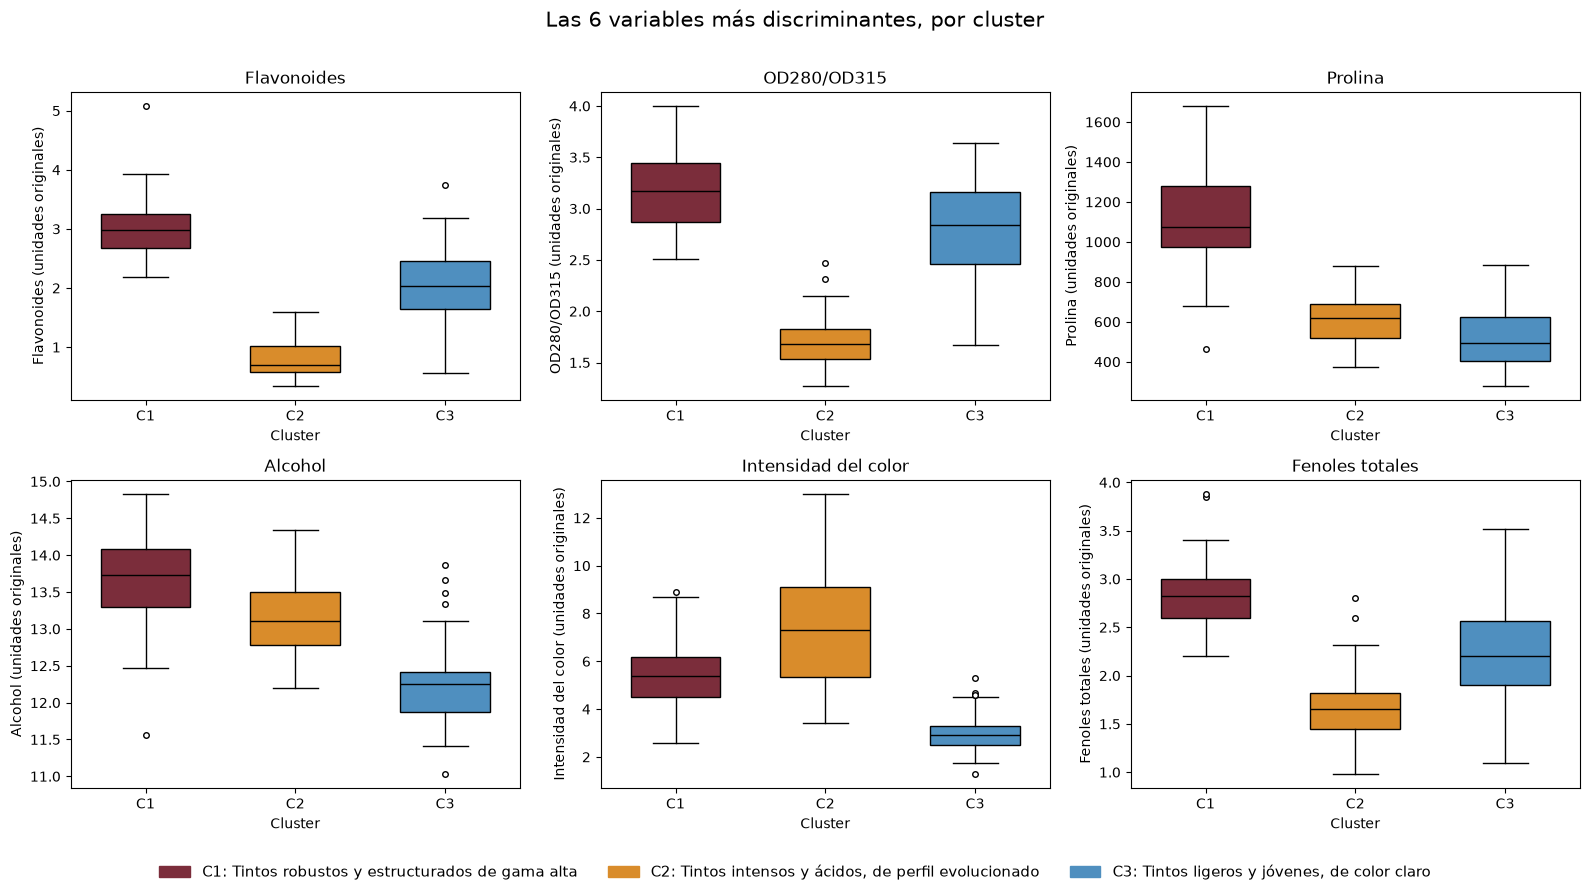

In [37]:
it.graficar_boxplots_por_cluster(df, etiquetas, ranking.index[:6].tolist(), nombres);

### 5.2 Visualización con PCA

El PCA se usa **solo para visualizar** (proyectar 13 dimensiones en 2): el clustering se hizo sobre las 13 variables escaladas.

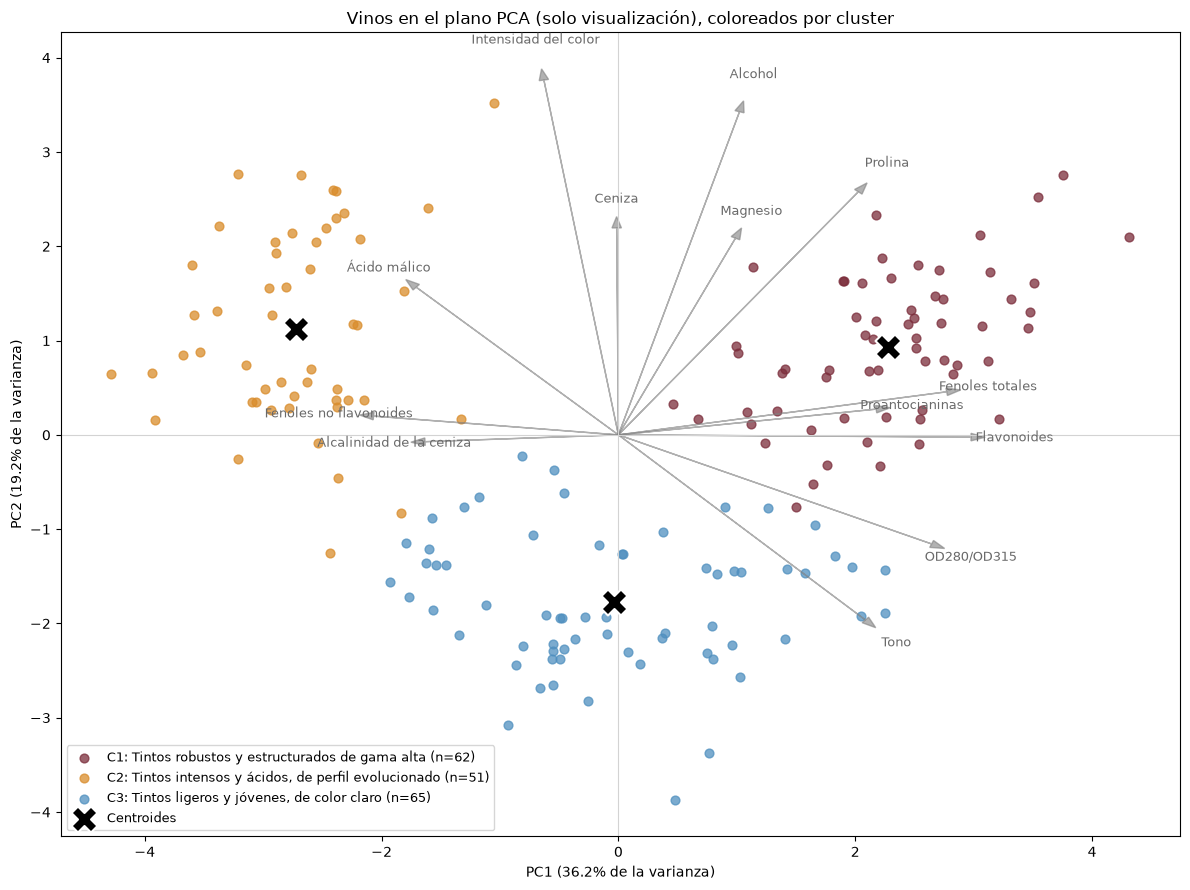

In [38]:
pca, proyecciones, loadings = it.ajustar_pca(df_esc)
centros_esc = escalador.transform(centroides)
it.graficar_pca(pca, proyecciones, loadings, etiquetas, centros_esc, nombres,
                "Vinos en el plano PCA (solo visualización), coloreados por cluster");

In [39]:
loadings.sort_values("PC1")

,PC1,PC2
variable,,
Fenoles no flavonoides,-0.299,0.029
Ácido málico,-0.245,0.225
Alcalinidad de la ceniza,-0.239,-0.011
Intensidad del color,-0.089,0.530
Ceniza,-0.002,0.316
Magnesio,0.142,0.300
Alcohol,0.144,0.484
Prolina,0.287,0.365
Tono,0.297,-0.279


Las dos primeras componentes explican el **55,4 %** de la varianza (36,2 % + 19,2 %).

- **PC1 = eje fenólico / de calidad tánica**: cargas positivas altas de Flavonoides (0,42), Fenoles totales (0,40), OD280/OD315
  (0,38) y Proantocianinas (0,31); negativas de Fenoles no flavonoides (−0,30), Ácido málico (−0,25) y Alcalinidad (−0,24). Separa
  **C2** (izquierda) de **C1** (derecha).
- **PC2 = eje de concentración / intensidad**: Intensidad del color (0,53), Alcohol (0,48), Prolina (0,37) y Magnesio (0,30), con
  Tono en negativo (−0,28). Separa **C3** (abajo: vinos ligeros y claros) de los otros dos.

Los tres grupos ocupan regiones bien diferenciadas del plano con un solapamiento pequeño en la frontera C3–C1/C2, coherente con
la silueta moderada y con los pocos vinos en los que K-Means y Ward discrepan.

## 6. Los tipos de vino identificados

Los nombres se asignan con una **regla explícita sobre los perfiles z** (implementada en `it.identificar_tipos`, no hardcodeada
por número de cluster):

- **robusto** = máximo de z(Prolina) + z(Alcohol) + z(Flavonoides);
- **intenso** = entre los restantes, máximo de z(Ácido málico) + z(Intensidad del color) − z(Tono) − z(Flavonoides);
- **ligero** = el restante.

Guía de interpretación enológica utilizada: Alcohol y Prolina → madurez de la uva, cuerpo; Fenoles totales, Flavonoides y
Proantocianinas → taninos, estructura, guarda; Fenoles no flavonoides → fracción fenólica "no noble"; Ácido málico → acidez verde;
Intensidad del color y Tono → profundidad de color y evolución (tono bajo = matices teja); OD280/OD315 → contenido fenólico/proteico
asociado a calidad. **El perfil sensorial y el uso comercial son inferencias** a partir de la química, no mediciones.

In [40]:
display(Markdown(it.fichas_a_markdown(fichas, pd.Series(etiquetas).value_counts())))

### C1 · Tintos robustos y estructurados de gama alta (62 vinos)

Es el grupo de mayor graduación alcohólica (13,68%) y con la Prolina más alta (1.100 frente a 747 de media), marcadores de uvas muy maduras. Concentra la mayor carga de polifenoles nobles: Flavonoides 3,00, Fenoles totales 2,85 y Proantocianinas 1,92, con la menor proporción de Fenoles no flavonoides (0,29). El OD280/OD315 alto (3,16) y un Tono alto (1,07, matices rojos vivos) completan un perfil de vino con cuerpo, taninos de calidad y aptitud para la guarda.

**Perfil químico dominante:**

- Prolina 1.100 (media global 747; z = 1,13)
- Alcohol 13,68 (media global 13,00; z = 0,84)
- Flavonoides 3,00 (media global 2,03; z = 0,98)
- Fenoles totales 2,85 (media global 2,30; z = 0,89)
- OD280/OD315 3,16 (media global 2,61; z = 0,78)

**Perfil sensorial (inferencia):** Cuerpo pleno, alcohol perceptible, taninos abundantes pero finos, color estable; potencial de envejecimiento en barrica y botella.

**Uso comercial sugerido (inferencia):** Segmento premium / reserva. Maridaje con carnes rojas asadas, caza, guisos y quesos duros estacionados.

### C2 · Tintos intensos y ácidos, de perfil evolucionado (51 vinos)

Tiene la mayor Intensidad del color (7,23) pero el Tono más bajo (0,69), es decir, color profundo con matices teja/anaranjados propios de un vino evolucionado. Es el más ácido: Ácido málico 3,31 (media 2,34). Sus Flavonoides son los más bajos (0,82) y los Fenoles no flavonoides los más altos (0,45), con OD280/OD315 mínimo (1,70): la fracción fenólica es menos 'noble', lo que sugiere taninos más rústicos pese al color intenso.

**Perfil químico dominante:**

- Intensidad del color 7,23 (media global 5,06; z = 0,94)
- Tono 0,69 (media global 0,96; z = -1,16)
- Ácido málico 3,31 (media global 2,34; z = 0,87)
- Flavonoides 0,82 (media global 2,03; z = -1,22)
- OD280/OD315 1,70 (media global 2,61; z = -1,29)

**Perfil sensorial (inferencia):** Color oscuro con reflejos teja, acidez marcada y vibrante, taninos menos pulidos; vino de consumo más temprano que de larga guarda.

**Uso comercial sugerido (inferencia):** Segmento medio. Acompaña bien platos grasos o con tomate (pastas, pizzas, embutidos) donde la acidez limpia el paladar.

### C3 · Tintos ligeros y jóvenes, de color claro (65 vinos)

Es el grupo de menor graduación (12,25%) y menor Intensidad del color (2,97, frente a 5,06 de media), con la Prolina más baja (510): uvas menos concentradas. El Tono alto (1,06) indica matices rojo-púrpura de vino joven. Sus polifenoles están en valores medios (Flavonoides 2,05) y su acidez málica es baja (1,90); también presenta el menor contenido mineral (Ceniza 2,23, Magnesio 92,7).

**Perfil químico dominante:**

- Alcohol 12,25 (media global 13,00; z = -0,93)
- Intensidad del color 2,97 (media global 5,06; z = -0,90)
- Prolina 510 (media global 747; z = -0,75)
- Tono 1,06 (media global 0,96; z = 0,46)
- Magnesio 92,7 (media global 99,7; z = -0,49)

**Perfil sensorial (inferencia):** Cuerpo ligero, color claro y vivo, alcohol moderado, taninos presentes pero sin gran concentración; perfil fresco y fácil de beber.

**Uso comercial sugerido (inferencia):** Segmento de entrada / consumo cotidiano, vino por copa. Maridaje con aperitivos, carnes blancas, pescados grasos o servido ligeramente fresco.


**Hipótesis (no conclusión) sobre las variedades.** En la bibliografía original del dataset (Forina et al., sistema PARVUS) las tres
variedades se asocian con **Barolo, Grignolino y Barbera** (uvas Nebbiolo, Grignolino y Barbera). Los perfiles obtenidos son
consistentes con lo que se conoce de ellas:

- **C1 ↔ Barolo** (Nebbiolo): vino potente, de alta graduación, muy tánico y de larga guarda.
- **C2 ↔ Barbera**: conocida por su **acidez alta**, color profundo y taninos relativamente bajos (aquí, Flavonoides mínimos).
- **C3 ↔ Grignolino**: tinto de **color pálido**, liviano y de menor graduación.

Esta correspondencia se formula a partir de la química y del conocimiento enológico, **antes** de mirar las etiquetas; en la sección
7 se contrasta.

## 7. Validación post-hoc con las etiquetas ocultas

> ⚠️ **Esta sección NO forma parte del aprendizaje.** La variedad real no se usó en ninguna decisión anterior (escalado, k, algoritmo,
> nombres). En un caso real no se dispondría de estas etiquetas; se usan aquí solo para evaluar, siguiendo el mismo esquema que la
> cátedra aplicó con Iris (descartar `species`, clusterizar y comparar al final).

Métricas: **ARI** (acuerdo corregido por azar), **NMI** (información mutua normalizada, 0–1) y **pureza** (proporción de vinos que
pertenecen a la variedad mayoritaria de su cluster).

In [41]:
variedad_real = cargar_etiquetas_ocultas()
contingencia, metricas_post = it.validacion_posthoc(etiquetas, variedad_real)
display(contingencia)
pd.Series(metricas_post).to_frame("valor")

Variedad real,1,2,3
Cluster,,,
1,59,3,0
2,0,3,48
3,0,65,0


,valor
ARI,0.897
NMI,0.876
Pureza,0.966
Vinos fuera de la variedad mayoritaria,6.000


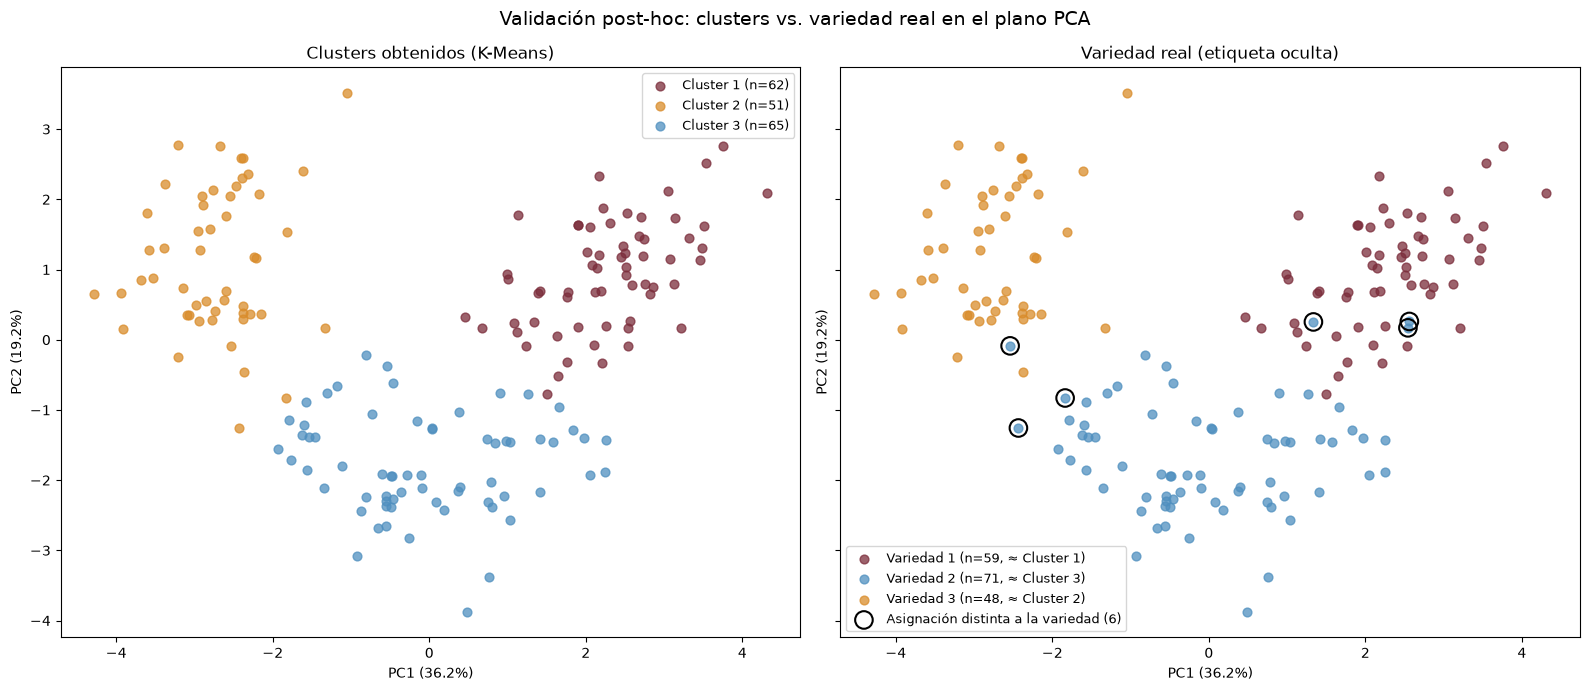

In [42]:
it.graficar_pca_clusters_vs_real(proyecciones, etiquetas, variedad_real, pca);

**Resultado.** ARI = **0,897**, NMI = **0,876** y pureza = **96,6 %**: solo 6 de 178 vinos quedan en un cluster cuya variedad
mayoritaria no es la suya.

- **C3** contiene exclusivamente vinos de la variedad 2 (65/65).
- **C1** agrupa 59 de los 59 vinos de la variedad 1 más 3 de la variedad 2.
- **C2** agrupa 48 de los 48 vinos de la variedad 3 más 3 de la variedad 2.

Todos los errores involucran a la **variedad 2**, que es la más heterogénea: 6 de sus 71 vinos tienen perfiles que se parecen más a
los de las otras variedades (se ven en la frontera del plano PCA, círculos negros). Es un resultado mucho más limpio que el de Iris
en clase (donde versicolor y virginica se mezclaban).

La correspondencia **C1 ↔ variedad 1, C2 ↔ variedad 3, C3 ↔ variedad 2** coincide con la hipótesis de la sección 6 si se asume el
orden de la bibliografía (1 = Barolo, 2 = Grignolino, 3 = Barbera).

## 8. Limitaciones y conclusiones

### Limitaciones de K-Means aplicadas a este caso
- **Inicialización aleatoria**: con `init='random'` y una corrida se obtuvieron 5 soluciones distintas (ARI mínimo 0,865). Se mitigó
  con `k-means++` y `n_init=10` (ARI mínimo 0,982), pero sigue habiendo 2 soluciones que difieren en vinos fronterizos.
- **Supuesto de clusters esféricos y de tamaño/densidad similar**: K-Means parte el espacio en regiones convexas (celdas de Voronoi).
  Aquí funciona porque los grupos son compactos y de tamaños parecidos (51–65); con grupos alargados o de densidades muy distintas
  fallaría.
- **Sensibilidad al escalado**: sin escalar, el modelo agrupa solo por Prolina (ARI 0,35 respecto de la solución escalada). El
  resultado depende de una decisión humana previa.
- **Sensibilidad a outliers**: la media se desplaza hacia los valores extremos; aquí los outliers son moderados y no cambiaron la
  partición, pero en otro dataset podrían hacerlo (RobustScaler o K-Medoids serían alternativas).
- **Solo variables numéricas** y **k fijado de antemano**.
- **Variables redundantes**: el bloque fenólico (4 variables con r > 0,6) pesa más en la distancia; no se aplicó selección ni
  ponderación de variables.
- Tamaño de muestra chico (178 vinos) y de una sola región: los nombres describen **estos** datos, no el universo de los tintos.

### Qué se haría distinto con más datos o con variables categóricas
Con variables categóricas (bodega, añada, región, tipo de barrica) se usaría **K-Modes** o **K-Prototypes** (mixtas); para grupos de
forma arbitraria y detección explícita de ruido, **DBSCAN**; para clusters elípticos con pertenencia probabilística (útil para los
vinos fronterizos), **Modelos de Mezcla Gaussiana (GMM)**. Solo se mencionan; no se implementaron.

### Conclusión
A partir de 13 mediciones químicas y sin conocer la variedad, el análisis encontró **tres tipos de vino tinto** bien definidos. Las
decisiones clave fueron escalar con z-score (sin él, Prolina decide el 99,95 % de la separación), conservar los outliers (no alteran
el resultado) y elegir **k = 3** por consenso de cinco criterios (codo, silueta 0,285, Calinski-Harabasz, Davies-Bouldin y
dendrograma). K-Means resultó estable (ARI entre semillas ≥ 0,98) y coincide con el jerárquico Ward (ARI 0,85). Los tipos son:
**tintos robustos y estructurados de gama alta** (62), **tintos intensos y ácidos, de perfil evolucionado** (51) y **tintos ligeros
y jóvenes, de color claro** (65). La validación post-hoc confirma que los grupos reproducen las variedades reales con una pureza del
96,6 % (ARI 0,90).